In [1]:
import numpy as np
import matplotlib.pyplot as plt

from resource_model import ResourceModel
from const import (IAI_TO_IMAGE_CLASSES)

In [2]:
# Aluminium regions

aluminium_regions = {
    'Africa' : ['Africa'], 
    'Asia (ex China)' : ['Asia (ex China)'], 
    'China (Estimated)' : ['China (Estimated)'],
    'Estimated Unreported to IAI' : ['Estimated Unreported to IAI'], 
    'Gulf Cooperation Council' : ['Gulf Cooperation Council'],
    'North America' : ['North America'], 
    'Oceania' : ['Oceania'], 
    'Russia & Eastern Europe' : ['Russia & Eastern Europe'],
    'South America' : ['South America'],
    'Western & Central Europe' : ['Western & Central Europe']
}



In [3]:
# Aluminium
aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                       image_mat_available = True, start_year = 1998, end_year = 2024)

aluminium.data_grouped_regions(regions_grouping = aluminium_regions) 

<Axes: >

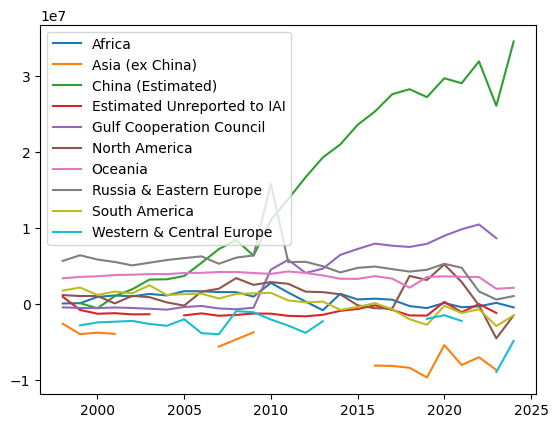

In [4]:
aluminium.sum_IMAGE_drivers_regions(IAI_TO_IMAGE_CLASSES)
aluminium.match_MAT_data_to_regions_year(match_external_regions=True)
aluminium.calculate_historic_other_fraction()
aluminium.historic_other_fraction_consumption.plot()

In [29]:
# test if there are negative values in other fraction 
aluminium.historic_other_fraction_consumption

# Share of IAMGE MAT data to total consumption
(aluminium.image_mat_material_regions.loc[:2017]/aluminium.historic_consumption_data.loc[:2017]*100).mean()

# Deal with negative values in other fraction
# Africa: all negative: assumption that apparent MAT is 60% of total consumption (mean until 2017)
# Asia: assume the same as for Europe

Africa                            61.486961
Asia (ex China)                24426.327314
China (Estimated)                 41.175972
Estimated Unreported to IAI      994.497014
Gulf Cooperation Council         397.385957
North America                     80.321125
Oceania                            6.340042
Russia & Eastern Europe           22.452934
South America                     71.431901
Western & Central Europe         479.536109
dtype: float64

In [28]:
aluminium.historic_other_fraction_consumption

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Fit models 
aluminium.calculate_regressors(aluminium.historic_other_fraction_consumption)
aluminium.fit_models()

Optimal parameters not found: Number of calls to function has reached maxfev = 800.


c:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:285: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * np.exp(-c * X))


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by LinearRegression.